In [1]:
import numpy as np
import matplotlib.pyplot as plt

import prn
import gps_sim

# Setup

In [16]:
x = np.fromfile("gpssim.bin", dtype=np.int16)
# x = np.sign(x, dtype=np.int8)

x = x[::2].astype(np.complex64) + 1j*x[1::2].astype(np.complex64)

f_s = 10.23e6
# sample_num = int(f_s*1)
# sats = [1, 2, 3, 4, 5]
# doppler_shifts = [950]*5
# x = np.zeros(sample_num, dtype=np.complex64)
# for i in range(len(sats)):
#     x = x + gps_sim.generate_gps(f_s, sample_num, sats[i], doppler_shifts[0], snr_db=None)
# x = gps_sim.generate_gps(
#     f_s=f_s,
#     n=sample_num,
#     sv=5,
#     doppler=1e3, # Hz
#     code_phase=0,
#     # signal_power=-130 # dBm
#     signal_power=-110 # dBm
# )

# Normalize to unity power
# x = x / np.sqrt(np.var(x))

# Acquisition

In [17]:
N = 2 ** 15
doppler = 20e3 # Max doppler shift in a single direction
bin_size = f_s / N
IF = 0

print(f"Searching {1e3*N/f_s:0.2f}ms period")
print(f"{bin_size:0.1f}Hz frequency bins")

# Pre compute FFT since it's the same for every iteration
X = np.fft.fft(x[0:N]).conj()

# sv, doppler shift (Hz), code phase (samples)
results = []

# Calculate frequency bins
shifts = np.arange(int((doppler)/bin_size), int((doppler)/bin_size)+1)
shift_freqs = shifts * bin_size

for sv in range(1, 33):
# for sv in [5]:
    # FFT of PRN
    Y = np.fft.fft(prn.sample(sv, f_s, N))
    z_arr = np.zeros((len(shifts), N))

    # Iterate through frequency shifts
    for i, shift in enumerate(shifts):
        Z = X * np.roll(Y, shift)
        z_arr[i] = np.abs(np.fft.ifft(Z))

    z_arr = z_arr[:, 0:int(f_s/1e3)] # Only look at first cycle of code
    shift, phase = np.unravel_index(np.argmax(z_arr), z_arr.shape) # Get freq and phase of max
    ratio = z_arr[shift, phase] / np.mean(z_arr[shift]) # Calculate ratio of max to average

    # If ratio is high enough, it's probably a real signal
    if ratio > 3:
        print(f"SV: {sv}, Doppler shift: {shift_freqs[shift]:0.2f}Hz, Code sample phase: {phase}, ratio: {ratio:0.1f}")
        results.append([sv, shift_freqs[shift], phase])

Searching 3.20ms period
312.2Hz frequency bins
SV: 1, Doppler shift: 19980.47Hz, Code sample phase: 6822, ratio: 3.2
SV: 2, Doppler shift: 19980.47Hz, Code sample phase: 4971, ratio: 3.4
SV: 3, Doppler shift: 19980.47Hz, Code sample phase: 9668, ratio: 3.4
SV: 4, Doppler shift: 19980.47Hz, Code sample phase: 1360, ratio: 3.3
SV: 5, Doppler shift: 19980.47Hz, Code sample phase: 6144, ratio: 3.5
SV: 6, Doppler shift: 19980.47Hz, Code sample phase: 1861, ratio: 3.4
SV: 7, Doppler shift: 19980.47Hz, Code sample phase: 9792, ratio: 3.4
SV: 8, Doppler shift: 19980.47Hz, Code sample phase: 4400, ratio: 3.2
SV: 9, Doppler shift: 19980.47Hz, Code sample phase: 6992, ratio: 3.1
SV: 10, Doppler shift: 19980.47Hz, Code sample phase: 7708, ratio: 3.1
SV: 11, Doppler shift: 19980.47Hz, Code sample phase: 6148, ratio: 3.7
SV: 12, Doppler shift: 19980.47Hz, Code sample phase: 9302, ratio: 3.2
SV: 13, Doppler shift: 19980.47Hz, Code sample phase: 1934, ratio: 3.3
SV: 14, Doppler shift: 19980.47Hz, Code

# Tracking

Stolen and modified from https://github.com/psas/gps/blob/master/Tracking.py

In [123]:
# Loop filter parameters
code_B_L = 2
# code_B_L = 0.00001 # Disable for debugging
code_zeta = 0.7
code_gain = 1
carrier_B_L = 25
# carrier_B_L = 15
# carrier_B_L = 0.000001
carrier_zeta = 0.7
carrier_gain = 0.25
T = 1e-3

code_length = f_s / 1e3 # Number of samples per cycle of code (1ms)

In [124]:
def calcLoopCoef(B_L: int, zeta: float, gain: float, T: float):
    '''
    Calculates the loop coefficients tau1 and tau2. 

    This process is discussed in sections 7.1-7.3 of Borre.
    '''
    # Solve for the natural frequency
    Wn = B_L*8*zeta / (4*zeta**2 + 1)

    # Solve for tau1 and tau2
    tau1 = gain / (Wn * Wn)
    tau2 = 2 * zeta / Wn

    coeff1 = tau2/tau1
    coeff2 = T/tau1

    return coeff1, coeff2

In [125]:
def track(x: np.ndarray, f_s: float, sv: int, f_carrier: float, code_phase: int):
    """_summary_

    Args:
        x (np.ndarray): Samples to be process
        f_s (float): Sampling frequency
        sv (int): SV number (of specific satellite)
        f_carrier (float): Carrier frequency found during acquisition
        code_phase (int): Code phase found during acquisition
    """

    # Calculate filter coefficient values for code loop
    code_C1, code_C2 = calcLoopCoef(code_B_L, code_zeta, code_gain, T)

    # Calculate filter coefficient values for carrier loop
    carrier_C1, carrier_C2 = calcLoopCoef(carrier_B_L, carrier_zeta, carrier_gain, T)

    codeFreq = 1.023e6
    ca_code = np.array(prn.generate(sv))
    # No idea why this stuff is needed
    ca_code = np.append(ca_code, ca_code[0])
    ca_code = np.insert(ca_code, 0, ca_code[len(ca_code) - 2])
    # ca_code_samples = prn.sample(sv, f_s, code_length)

    # Residual code/carrier phase
    remCodePhase = 0.0

    # define residual carrier phase
    remCarrPhase  = 0.0

    # code tracking loop parameters
    oldCodeNco   = 0.0
    oldCodeError = 0.0

    # carrier/Costas loop parameters
    oldCarrNco   = 0.0
    oldCarrError = 0.0

    dataPosition = 0

    carrFreq = f_carrier

    # Might want to make these configurable, idk
    ms = int(np.floor(len(x) * 1e3 / f_s))
    codeLength = 1023
    earlyLateSpacing = 0.5
    chippingRate = 1.023e6

    # Arrays to store results
    arr_carr_error = np.zeros(ms)
    arr_carr_freq = np.zeros(ms)
    arr_code_error = np.zeros(ms)
    arr_code_freq = np.zeros(ms)
    arr_ip = np.zeros(ms)
    arr_qp = np.zeros(ms)

    # Process the requested number of code periods (num of ms to process)
    for loopCount in range(0, ms):
        # Update the phasestep based on code freq (variable) and
        # sampling frequency (fixed)
        codePhaseStep = np.real(codeFreq / f_s)

        blksize = int(np.ceil((codeLength-remCodePhase) / codePhaseStep))

        # Read in the appropriate number of samples to process this
        # iteration
        rawSignal = x[code_phase + dataPosition:code_phase + dataPosition + blksize]
        dataPosition = dataPosition + blksize

        # Handle last block
        if len(rawSignal) != blksize:
            if len(rawSignal) == 0:
                break
            blksize = len(rawSignal)

        # TODO: should this use samples instead?
        # Reference code index
        tcode = np.linspace(remCodePhase,((blksize-1)*codePhaseStep+remCodePhase) + codePhaseStep,blksize,endpoint=False)

        # Early and late were switched
        # Generate Early CA Code
        earlyCode = ca_code[np.ceil(tcode + earlyLateSpacing).astype(int)]

        # Generate Late CA Code
        lateCode = ca_code[np.ceil(tcode - earlyLateSpacing).astype(int)]

        # Generate Prompt CA Code
        promptCode = ca_code[np.ceil(tcode).astype(int)]

        # Figure out remaining code phase (uses tcode from Prompt CA Code generation):
        remCodePhase = (tcode[blksize-1]) - 1023.00
        if abs(remCodePhase) > codePhaseStep:
            remCodePhase = np.sign(remCodePhase)*codePhaseStep
        else:
            remCodePhase = 0

        # Generate the carrier frequency to mix the signal to baseband
        time = np.arange(blksize+1)/f_s

        # Get the argument to sin/cos functions
        trigarg = carrFreq * 2 * np.pi * time + remCarrPhase

        # Carry the leftover phase to the next argument by looking at the last element
        remCarrPhase = trigarg[blksize] % (2 * np.pi)

        # First mix to baseband
        basebandSignal = rawSignal * np.exp(1j*trigarg[0:blksize])

        # Now get early, late, and prompt values for each
        iqEarly = earlyCode * basebandSignal
        iqPrompt = promptCode * basebandSignal
        iqLate = lateCode * basebandSignal
        I_E = np.sum(iqEarly.real)
        Q_E = np.sum(iqEarly.imag)
        I_P = np.sum(iqPrompt.real)
        Q_P = np.sum(iqPrompt.imag)
        I_L = np.sum(iqLate.real)
        Q_L = np.sum(iqLate.imag)

        # Find PLL error and update carrier NCO
        # Implement carrier loop discriminator (phase detector)
        carrError = np.arctan(Q_P / I_P) / (2.0 * np.pi)
        # carrError = np.sign(Q_P) * np.sign(I_P) / 4
        # carrError = Q_P / np.mean(np.sqrt(I_P**2 + Q_P**2))
        # carrError = (I_E * Q_L - I_L * Q_E) * T

        # Implement carrier loop filter and generate NCO command
        carrNco = oldCarrNco + carrier_C1 * (carrError - oldCarrError) + carrError * carrier_C2
        oldCarrNco   = carrNco
        oldCarrError = carrError

        # Modify carrier freq based on NCO command
        # carrFreq = f_carrier + carrNco
        carrFreq = f_carrier - carrNco

        # Find DLL error and update code NCO -------------------------------------
        codeError = (np.sqrt(I_E * I_E + Q_E * Q_E) - np.sqrt(I_L * I_L + Q_L * Q_L)) /\
                    (np.sqrt(I_E * I_E + Q_E * Q_E) + np.sqrt(I_L * I_L + Q_L * Q_L))
        # codeError = ((I_E * I_E + Q_E * Q_E) - (I_L * I_L + Q_L * Q_L)) /\
        #             ((I_E * I_E + Q_E * Q_E) + (I_L * I_L + Q_L * Q_L))
        # codeError = (I_E - I_L) / I_P

        # Implement code loop filter and generate NCO command
        codeNco = oldCodeNco + code_C1 * (codeError - oldCodeError) + codeError * code_C2
        oldCodeNco   = codeNco
        oldCodeError = codeError

        # Modify code freq based on NCO command
        codeFreq = chippingRate - codeNco
        # codeFreq = chippingRate + codeNco

        arr_carr_error[loopCount] = carrError
        arr_carr_freq[loopCount] = carrFreq
        arr_code_error[loopCount] = codeError
        arr_code_freq[loopCount] = codeFreq
        arr_ip[loopCount] = I_P
        arr_qp[loopCount] = Q_P

    return arr_ip, arr_qp, arr_carr_freq, arr_carr_error, arr_code_freq, arr_code_error

In [126]:
# Attempt tracking
end = int(f_s*1)
i = 0
sv = results[i][0]
f_carrier = results[i][1]
f_carrier = 1050
code_phase = results[i][2]*1023/N
# code_phase = 123
arr_ip, arr_qp, arr_carr_freq, arr_carr_error, arr_code_freq, arr_code_error = track(x[0:end], f_s, sv, f_carrier, int(np.round(code_phase)))

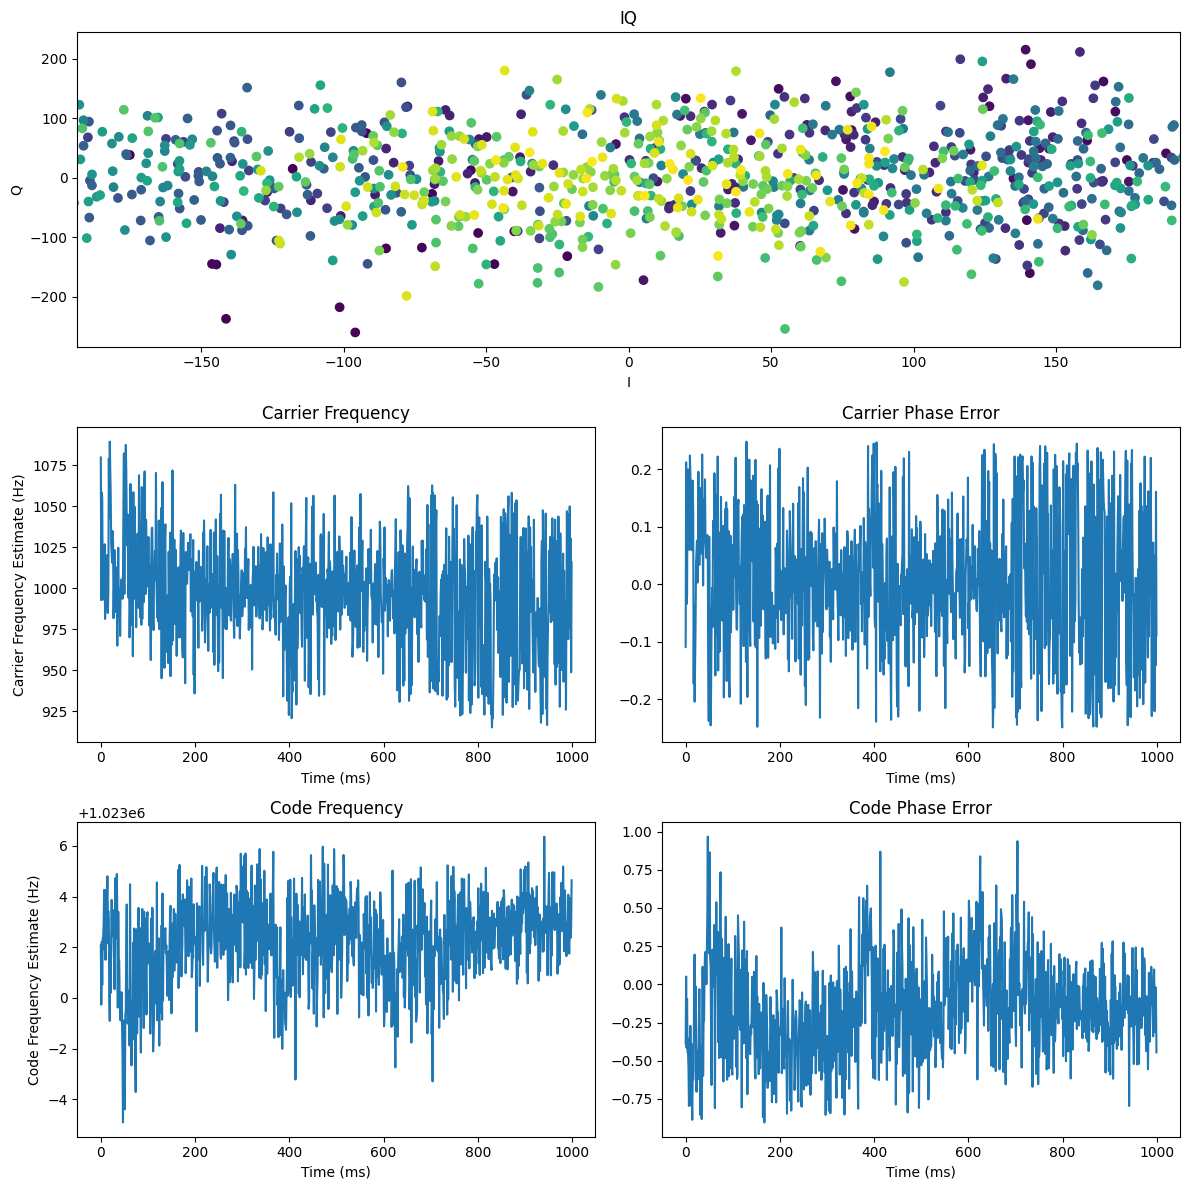

In [127]:
plt.figure(figsize=(12, 12))

plt.subplot(3, 2, (1, 2))
plt.scatter(arr_ip, arr_qp, c=np.arange(len(arr_ip)))
p = np.mean(np.abs(arr_ip + 1j*arr_qp))
plt.xlim([-p*1.5, p*1.5])
# plt.ylim([-100, 100])
plt.title("IQ")
plt.xlabel("I")
plt.ylabel("Q")

plt.subplot(3, 2, 3)
plt.plot(arr_carr_freq)
plt.title("Carrier Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Carrier Frequency Estimate (Hz)")

plt.subplot(3, 2, 4)
plt.plot(arr_carr_error)
plt.title("Carrier Phase Error")
plt.xlabel("Time (ms)")

plt.subplot(3, 2, 5)
plt.plot(arr_code_freq)
plt.title("Code Frequency")
plt.xlabel("Time (ms)")
plt.ylabel("Code Frequency Estimate (Hz)")

plt.subplot(3, 2, 6)
plt.plot(arr_code_error)
plt.title("Code Phase Error")
plt.xlabel("Time (ms)")

plt.tight_layout()

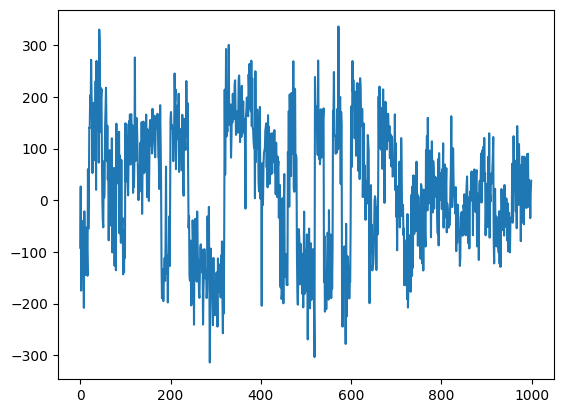

In [128]:
plt.plot(arr_ip)